# Motion Blur Analysis

Quantifies the effect of translational motion blur on localisation precision and colour precision
using the elliptical S3M fitting pipeline (`FittingStrategy.ELLIPTICAL`).

**Motion model:** constant velocity in a random direction during a 100 ms frame exposure.
Per-frame displacement = velocity × 0.1 s.  Each frame gets an independent random direction.

**Structure**
1. PSF shape visualisation — Gaussian PSF at increasing motion blur displacement
2. Velocity sweep simulation — N velocities × 3 photon levels × 3 dyes
3. Analysis — localisation precision, colour precision, and PSF ellipticity vs velocity

In [1]:
import sys, os, glob, types
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

sys.path.append(str(Path(os.getcwd()).parent.parent))

from src import IOFunctions, SpectralFunctions, MaskFunctions, sCMOSFunctions, PlottingBase
from src.Multicolour_Simulation_Functions import (
    FittingStrategy, SimulationConfig, MultiC_Sim_Funcs,
)

IO    = IOFunctions.IO_Functions()
S_F   = SpectralFunctions.Spectral_Funcs()
M_F   = MaskFunctions.Mask_Functions()
sCMOS = sCMOSFunctions.sCMOS_Functions()
MSF   = MultiC_Sim_Funcs()
plotter = PlottingBase.PublicationPlotter()

In [2]:
# ── Camera calibration ────────────────────────────────────────────────────────
cal_folder = Path("../../Camera_Calibrations/Ximea_Camera/")
gain      = IO.read_tiff(str(cal_folder / "gain.tif"))
offset    = IO.read_tiff(str(cal_folder / "offset.tif"))
variance  = IO.read_tiff(str(cal_folder / "variance.tif"))
readnoise = float(np.median(IO.read_tiff(str(cal_folder / "readnoise.tif"))))
rqe       = IO.read_tiff(str(cal_folder / "rqe.tif"))

print(f"Camera calibration loaded — sensor: {gain.shape}, readnoise: {readnoise:.2f}")

Camera calibration loaded — sensor: (1544, 2064), readnoise: 2.34


In [3]:
# ── Spectral setup ────────────────────────────────────────────────────────────
R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])   # (3, n_wl); convention B=0, G=1, R=2

dyes          = ["ATTO 488", "ATTO 565", "ATTO 647N"]
filters       = []
NA            = 1.49
pixel_size_nm = 69.0        # Ximea object-space pixel (nm)
image_dims    = 22          # 22 × 22 px
background_photons = 40.0
frame_exposure_ms  = 100.0  # fixed 100 ms frame exposure

smoothing_function = types.SimpleNamespace(
    args={"sigma": 1.5},
    extent=1.5,
    smoothing_function=sCMOS.gaussian_filter_stack,
    data_arg="image",
)

print(f"Wavelength grid: {wavelength[0]:.0f}–{wavelength[-1]:.0f} nm  ({len(wavelength)} pts)")

Wavelength grid: 400–999 nm  (600 pts)


In [4]:
# ── Save folder ───────────────────────────────────────────────────────────────
save_folder = Path("/home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260623_MotionBlur")
save_folder.mkdir(parents=True, exist_ok=True)
print(f"Results → {save_folder}")

Results → /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260623_MotionBlur


## Figure 1: PSF shape under motion blur

Time-integrated Gaussian PSF at increasing displacement (velocity × 100 ms exposure).  
No noise, no camera effects — shows the pure effect of the motion blur kernel.

In [11]:
# ── Compute motion-blurred PSFs for visualisation ─────────────────────────────
# Use a fine pixel grid to resolve the Airy disk structure.
from src.simulation.multicolour import MultiC_Sim_Funcs_Refactored

pix_vis_nm  = 10.0          # 10 nm/px oversampling
psf_size_vis = 201          # 2.01 µm window
sigma_vis_nm = 120.0        # approximate Gaussian sigma for a 488 nm dye, NA 1.49

# Displacements to show: 0, 50, 100, 200, 400 nm (= 0, 500, 1000, 2000, 4000 nm/s × 100 ms)
displacements_nm = np.array([0, 100, 250, 500, 1000], dtype=float)
n_disp = len(displacements_nm)

# Build analytic Gaussian PSF callable on a (psf_size_vis × psf_size_vis) grid
_cx = psf_size_vis / 2.0
xx, yy = np.meshgrid(np.arange(psf_size_vis), np.arange(psf_size_vis), indexing="ij")
sigma_px = sigma_vis_nm / pix_vis_nm

def _gauss_fn(x0, y0, _n):
    g = np.exp(-((xx - x0)**2 + (yy - y0)**2) / (2 * sigma_px**2))
    return (g / g.sum()).astype(np.float32)

psf_vis_stack = []
np.random.seed(42)
for d_nm in displacements_nm:
    d_px = d_nm / pix_vis_nm
    if d_px == 0.0:
        psf_vis_stack.append(_gauss_fn(_cx, _cx, None))
    else:
        angle = np.random.uniform(0, 2 * np.pi)  # representative single angle
        psf_vis_stack.append(
            MultiC_Sim_Funcs_Refactored._apply_motion_blur(
                _gauss_fn, np.array([_cx]), np.array([_cx]), np.array([1]),
                d_px, angle, n_samples=51,
            )
        )

print(f"Computed {n_disp} PSF images  (pixel size {pix_vis_nm} nm, σ = {sigma_vis_nm} nm)")

Computed 5 PSF images  (pixel size 10.0 nm, σ = 120.0 nm)


/tmp/ipykernel_336148/3807301558.py:24: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0.05)
INFO:src.PlottingBase:Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260623_MotionBlur/psf_motion_blur_panels.svg


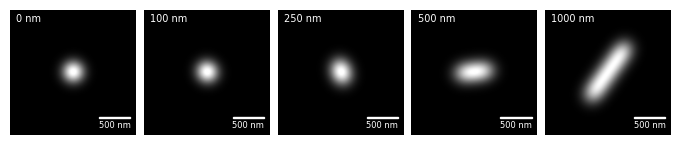

Figure 1 saved.


In [12]:
# ── Figure 1: motion-blurred PSF panels ──────────────────────────────────────
fig, axs = plotter.two_column_plot(nrows=1, ncols=n_disp, height=6.69 / n_disp + 0.1)
fs = plotter.config.font_size

for i_d, (d_nm, psf) in enumerate(zip(displacements_nm, psf_vis_stack)):
    I_disp = psf / psf.max()
    plotter.image_plot(
        axs[i_d], I_disp,
        cmap="gray",
        vmin=np.percentile(I_disp, 1), vmax=np.percentile(I_disp, 99.9),
        scalebar=True, pixelsize=pix_vis_nm,
        scalebarsize=500.0, scalebarlabel="500 nm",
        scalebar_color="white", origin="lower",
        colorbar=False,
    )
    label = f"{d_nm:.0f} nm" if d_nm > 0 else "0 nm"
    axs[i_d].text(
        0.05, 0.97, label,
        transform=axs[i_d].transAxes,
        fontsize=fs, color="white", va="top", ha="left",
        bbox=dict(boxstyle="square,pad=0.15", fc="none", ec="none"),
    )

fig.subplots_adjust(wspace=0.05)
plotter.save_or_show(fig, save_path=str(save_folder / "psf_motion_blur_panels.svg"), show=True)
print("Figure 1 saved.")

## Velocity Sweep Simulation

For each (dye, velocity), run `test_simulation_method` with `FittingStrategy.ELLIPTICAL`
across three photon levels.  The elliptical fitter recovers separate σ_x, σ_y, and θ per localisation,
so the blur-induced PSF elongation is captured directly rather than being averaged into a wider circular σ.

Velocities span 0–5000 nm/s → displacements 0–500 nm at 100 ms exposure
(0–7.2 pixels at 69 nm/px).

In [14]:
# ── Sweep parameters ─────────────────────────────────────────────────────────
velocities_nm_per_s = np.array([0, 100, 250, 500, 1000, 2000, 3000, 5000, 7500, 10000], dtype=float)
displacements_sweep_nm = velocities_nm_per_s * (frame_exposure_ms / 1000.0)

n_photon_space = np.geomspace(500, 20000, 100)
n_bootstrap    = 10000

print(f"Velocities (nm/s): {velocities_nm_per_s}")
print(f"Displacements (nm): {displacements_sweep_nm}")
print(f"\nSweep: {len(dyes)} dyes × {len(velocities_nm_per_s)} velocities")
print(f"Total simulation calls: {len(dyes) * len(velocities_nm_per_s)}")

Velocities (nm/s): [     0.    100.    250.    500.   1000.   2000.   3000.   5000.   7500.
  10000.]
Displacements (nm): [    0.    10.    25.    50.   100.   200.   300.   500.   750.  1000.]

Sweep: 3 dyes × 10 velocities
Total simulation calls: 30


In [15]:
# ── Camera parameters dictionary ──────────────────────────────────────────────
def make_camera_params(image_dims):
    return {
        "gain":               np.full((image_dims, image_dims), np.median(gain)),
        "offset":             np.full((image_dims, image_dims), np.median(offset)),
        "variance":           np.full((image_dims, image_dims), np.median(variance)),
        "readnoise":          readnoise,
        "rqe":                np.full((image_dims, image_dims), np.median(rqe)),
        "masks":              M_F.get_masks(size_x=image_dims, size_y=image_dims),
        "pixel_QYs":          pixel_QYs,
        "pixel_order":        ["B", "G", "R"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
    }

camera_params_dict = make_camera_params(image_dims)
print(f"Camera parameters ready — image size: {image_dims}×{image_dims} px")

Camera parameters ready — image size: 22×22 px


In [16]:
# ── Run sweep ─────────────────────────────────────────────────────────────────
import time

n_total = len(dyes) * len(velocities_nm_per_s)
i_run   = 0
t_start = time.time()

for dye in dyes:
    for v_nm_s in velocities_nm_per_s:
        i_run += 1
        flag = f"motionblur_v{v_nm_s:06.0f}nms_"

        config = SimulationConfig(
            n_bootstrap=n_bootstrap,
            background_photons=background_photons,
            NA=NA,
            pixel_size=pixel_size_nm,
            save_raw_results=True,
            subtractx0y0=False,
            use_stochastic_photons=True,
            save_summary_csvs=True,
            verbose=False,
            motion_velocity_nm_per_s=float(v_nm_s),
            frame_exposure_ms=frame_exposure_ms,
        )

        disp_nm = v_nm_s * (frame_exposure_ms / 1000.0)
        print(
            f"[{i_run:3d}/{n_total}]  {dye}  v={v_nm_s:.0f} nm/s  "
            f"(displacement {disp_nm:.0f} nm)",
            end="  ", flush=True,
        )

        MSF.test_simulation_method(
            dye=dye,
            filters=filters,
            wavelength=wavelength,
            camera_parameters=camera_params_dict,
            save_folder=str(save_folder),
            n_photon_space=n_photon_space,
            smoothing_function=smoothing_function,
            strategy=FittingStrategy.ELLIPTICAL,
            starting_flag=flag,
            config=config,
            overwrite=True,
        )

        elapsed = (time.time() - t_start) / 60.0
        rate    = i_run / elapsed if elapsed > 0 else 0
        eta     = (n_total - i_run) / rate if rate > 0 else 0
        print(f"done   ({elapsed:.1f} min elapsed, ETA {eta:.1f} min)")

print(f"\nSweep complete in {(time.time()-t_start)/60:.1f} min.")

INFO:simulation.multicolour:
Completed analysis of 100 photon flux values    Total time: 15.700 min
INFO:simulation.multicolour:Simulation completed for strategy elliptical


done   (15.7 min elapsed, ETA 455.4 min)
[  2/30]  ATTO 488  v=100 nm/s  (displacement 10 nm)  

UnboundLocalError: cannot access local variable 's' where it is not associated with a value

## Analysis

Load the RMSE summary CSVs and the raw HDF5 results.  
The raw results contain `theta` (fitted blur angle) and separate `s_x`, `s_y`,  
which directly quantify the blur-induced PSF ellipticity.

In [ ]:
# ── Load RMSE summary CSVs ────────────────────────────────────────────────────
results = {}   # (dye, v_nm_s, n_photon) → dict
missing = []

for dye in dyes:
    dye_str = dye.replace("/", "-")
    for v_nm_s in velocities_nm_per_s:
        flag = f"motionblur_v{v_nm_s:06.0f}nms_"
        pattern = str(save_folder / f"{flag}*{dye_str}*RMSE_mean*.csv")
        files = sorted(glob.glob(pattern))
        if not files:
            missing.append((dye, v_nm_s))
            continue
        df = pl.read_csv(files[0])
        for row in df.iter_rows(named=True):
            n_ph = float(row["n_photons"])
            results[(dye, v_nm_s, n_ph)] = {
                "sigma_x":     row["xc"],
                "sigma_y":     row["yc"],
                "sigma_xy":    float(np.sqrt((row["xc"]**2 + row["yc"]**2) / 2)),
                "colour_dist": row["colour_distance"],
            }

print(f"Loaded {len(results)} result entries.")
if missing:
    print(f"Missing: {missing}")

In [ ]:
# ── Load raw HDF5 to extract s_x, s_y, theta distributions ──────────────────
# For each (dye, velocity), load the raw results and compute median s_x, s_y, |theta|
raw_shape = {}   # (dye, v_nm_s, n_ph) → {"s_x": median_px, "s_y": median_px, "ellipticity": ratio}

for dye in dyes:
    dye_str = dye.replace("/", "-")
    for v_nm_s in velocities_nm_per_s:
        flag = f"motionblur_v{v_nm_s:06.0f}nms_"
        h5_path = save_folder / f"{flag}LM_method_{dye_str}_rawresults.h5"
        if not h5_path.exists():
            continue
        try:
            import pandas as pd
            df_raw = pd.read_hdf(str(h5_path), key="data")
            for ph_level_idx, n_ph in enumerate(n_photon_space):
                subset = df_raw[df_raw["photon_level"] == ph_level_idx]
                if len(subset) == 0:
                    continue
                sx = subset["s_x"].dropna().to_numpy() * pixel_size_nm  # px → nm
                sy = subset["s_y"].dropna().to_numpy() * pixel_size_nm
                # ellipticity = s_major / s_minor (always ≥ 1)
                s_major = np.maximum(sx, sy)
                s_minor = np.minimum(sx, sy)
                with np.errstate(divide="ignore", invalid="ignore"):
                    ellipticity = np.where(s_minor > 0, s_major / s_minor, np.nan)
                raw_shape[(dye, v_nm_s, float(n_ph))] = {
                    "s_x_nm":      float(np.nanmedian(sx)),
                    "s_y_nm":      float(np.nanmedian(sy)),
                    "s_mean_nm":   float(np.nanmedian(np.sqrt(sx * sy))),  # geometric mean
                    "ellipticity": float(np.nanmedian(ellipticity)),
                }
        except Exception as e:
            print(f"  Could not load {h5_path.name}: {e}")

print(f"Loaded raw shape data for {len(raw_shape)} (dye, velocity, photon) combinations.")

In [ ]:
# ── Plotting helpers ──────────────────────────────────────────────────────────
dye_colours = {"ATTO 488": "#1565C0", "ATTO 565": "#E65100", "ATTO 647N": "#B71C1C"}
dye_labels  = {"ATTO 488": "ATTO 488", "ATTO 565": "ATTO 565", "ATTO 647N": "ATTO 647N"}
ph_ls       = {500.0: ":", 1000.0: "-", 2000.0: "--"}   # line style by photon level
ph_alpha    = {500.0: 0.6, 1000.0: 1.0, 2000.0: 0.75}

fs = plotter.config.font_size
x_axis = displacements_sweep_nm   # nm displacement, more physical than velocity

In [ ]:
# ── Figure 2: localisation precision σ_xy vs displacement ────────────────────
# One panel per dye; three lines per panel (one per photon level).
n_dyes = len(dyes)
fig, axs = plotter.two_column_plot(nrows=1, ncols=n_dyes, height=2.5)

for i_dye, dye in enumerate(dyes):
    ax = axs[i_dye]
    for n_ph in n_photon_space:
        y = [
            results[(dye, v, float(n_ph))]["sigma_xy"]
            if (dye, v, float(n_ph)) in results else np.nan
            for v in velocities_nm_per_s
        ]
        ax.plot(
            x_axis, y,
            color=dye_colours[dye],
            ls=ph_ls[n_ph],
            alpha=ph_alpha[n_ph],
            lw=1.2,
            label=f"{n_ph:.0f} ph" if i_dye == 0 else None,
        )
    ax.set_xlabel("Displacement / nm", fontsize=fs)
    if i_dye == 0:
        ax.set_ylabel(r"$\sigma_{xy}$ / nm", fontsize=fs)
    ax.set_title(dye_labels[dye], fontsize=fs)
    ax.tick_params(labelsize=fs - 1)
    ax.set_xlim([0, x_axis.max()])
    ax.set_ylim(bottom=0)

axs[0].legend(fontsize=fs - 1, frameon=False, loc="upper left")
fig.tight_layout(pad=0.4)
plotter.save_or_show(fig, save_path=str(save_folder / "localisation_precision_vs_velocity.pdf"))

In [ ]:
# ── Figure 3: colour precision vs displacement ────────────────────────────────
fig, axs = plotter.two_column_plot(nrows=1, ncols=n_dyes, height=2.5)

for i_dye, dye in enumerate(dyes):
    ax = axs[i_dye]
    for n_ph in n_photon_space:
        y = [
            results[(dye, v, float(n_ph))]["colour_dist"]
            if (dye, v, float(n_ph)) in results else np.nan
            for v in velocities_nm_per_s
        ]
        ax.plot(
            x_axis, y,
            color=dye_colours[dye],
            ls=ph_ls[n_ph],
            alpha=ph_alpha[n_ph],
            lw=1.2,
            label=f"{n_ph:.0f} ph" if i_dye == 0 else None,
        )
    ax.set_xlabel("Displacement / nm", fontsize=fs)
    if i_dye == 0:
        ax.set_ylabel(r"$\sigma_{\mathrm{colour}}$ (a.u.)", fontsize=fs)
    ax.set_title(dye_labels[dye], fontsize=fs)
    ax.tick_params(labelsize=fs - 1)
    ax.set_xlim([0, x_axis.max()])
    ax.set_ylim(bottom=0)

axs[0].legend(fontsize=fs - 1, frameon=False, loc="upper left")
fig.tight_layout(pad=0.4)
plotter.save_or_show(fig, save_path=str(save_folder / "colour_precision_vs_velocity.pdf"))

In [ ]:
# ── Figure 4: PSF ellipticity vs displacement (from raw fit results) ──────────
# Ellipticity = σ_major / σ_minor (geometric mean of fitted widths).
# At zero blur this should be ≈ 1; it rises as the PSF becomes elongated.
fig, axs = plotter.two_column_plot(nrows=1, ncols=n_dyes, height=2.5)

for i_dye, dye in enumerate(dyes):
    ax = axs[i_dye]
    for n_ph in n_photon_space:
        y = [
            raw_shape[(dye, v, float(n_ph))]["ellipticity"]
            if (dye, v, float(n_ph)) in raw_shape else np.nan
            for v in velocities_nm_per_s
        ]
        ax.plot(
            x_axis, y,
            color=dye_colours[dye],
            ls=ph_ls[n_ph],
            alpha=ph_alpha[n_ph],
            lw=1.2,
            label=f"{n_ph:.0f} ph" if i_dye == 0 else None,
        )
    ax.axhline(1.0, color="gray", lw=0.6, ls=":")  # reference: perfect circle
    ax.set_xlabel("Displacement / nm", fontsize=fs)
    if i_dye == 0:
        ax.set_ylabel(r"Ellipticity $\sigma_{\mathrm{maj}}/\sigma_{\mathrm{min}}$", fontsize=fs)
    ax.set_title(dye_labels[dye], fontsize=fs)
    ax.tick_params(labelsize=fs - 1)
    ax.set_xlim([0, x_axis.max()])
    ax.set_ylim(bottom=1.0)

axs[0].legend(fontsize=fs - 1, frameon=False, loc="upper left")
fig.tight_layout(pad=0.4)
plotter.save_or_show(fig, save_path=str(save_folder / "psf_ellipticity_vs_velocity.pdf"))

In [ ]:
# ── Figure 5: combined summary at 1000 photons ────────────────────────────────
n_ph_summary = 1000.0

fig, axs = plotter.two_column_plot(nrows=1, ncols=3, height=2.5)
ax_loc, ax_col, ax_ell = axs[0], axs[1], axs[2]

for dye in dyes:
    kw = dict(color=dye_colours[dye], lw=1.2, label=dye_labels[dye])

    xy_vals = [
        results[(dye, v, n_ph_summary)]["sigma_xy"]
        if (dye, v, n_ph_summary) in results else np.nan
        for v in velocities_nm_per_s
    ]
    col_vals = [
        results[(dye, v, n_ph_summary)]["colour_dist"]
        if (dye, v, n_ph_summary) in results else np.nan
        for v in velocities_nm_per_s
    ]
    ell_vals = [
        raw_shape[(dye, v, n_ph_summary)]["ellipticity"]
        if (dye, v, n_ph_summary) in raw_shape else np.nan
        for v in velocities_nm_per_s
    ]

    ax_loc.plot(x_axis, xy_vals, **kw)
    ax_col.plot(x_axis, col_vals, **kw)
    ax_ell.plot(x_axis, ell_vals, **kw)

ax_ell.axhline(1.0, color="gray", lw=0.6, ls=":")

for ax, ylabel in [
    (ax_loc, r"$\sigma_{xy}$ / nm"),
    (ax_col, r"$\sigma_{\mathrm{colour}}$ (a.u.)"),
    (ax_ell, r"Ellipticity"),
]:
    ax.set_xlabel("Displacement / nm", fontsize=fs)
    ax.set_ylabel(ylabel, fontsize=fs)
    ax.tick_params(labelsize=fs - 1)
    ax.set_xlim([0, x_axis.max()])
    ax.set_ylim(bottom=0 if ax is not ax_ell else 1.0)

ax_loc.set_title(f"Localisation precision ({n_ph_summary:.0f} ph)", fontsize=fs)
ax_col.set_title(f"Colour precision ({n_ph_summary:.0f} ph)", fontsize=fs)
ax_ell.set_title(f"PSF ellipticity ({n_ph_summary:.0f} ph)", fontsize=fs)
ax_loc.legend(fontsize=fs - 1, frameon=False, loc="upper left")

fig.tight_layout(pad=0.4)
plotter.save_or_show(
    fig, save_path=str(save_folder / f"summary_{n_ph_summary:.0f}ph_motionblur.pdf")
)